In [19]:
from torch.optim import AdamW # Import AdamW from torch.optim
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os

In [20]:
# --- 1. 配置 ---
file_path = 'D:\\GitHubRepos\\is6400-business-data-analytics\\data\\loan_data.csv'

# --- Hyperparameters ---
MODEL_NAME = 'bert-base-uncased' # 可以尝试其他BERT变体，如 'bert-base-chinese' 如果特征名是中文
MAX_LENGTH = 128 # 输入文本的最大长度 (token数量)，根据需要调整
BATCH_SIZE = 64  # 批处理大小，根据GPU内存调整
EPOCHS = 5       # 训练轮数，可以增加以可能提高性能，但也可能过拟合
LEARNING_RATE = 2e-5 # 学习率

In [21]:
# --- 2. 数据加载与预处理 ---
print("开始加载和预处理数据...")

# # 在实际使用中，请取消注释下面这行来加载完整数据
try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"错误：找不到文件 {file_path}")
    exit()

# 检查并处理缺失值 (NaN) - 这里使用简单填充，实践中可能需要更复杂的策略
# 数值列用中位数填充，类别列用 'missing' 填充
print("处理缺失值...")
for col in df.columns:
    if df[col].isnull().any():
        print(f"列 '{col}' 存在缺失值。")
        if pd.api.types.is_numeric_dtype(df[col]):
            median_val = df[col].median()
            df[col].fillna(median_val, inplace=True)
            print(f"  用中位数 {median_val} 填充。")
        else:
            df[col].fillna('missing', inplace=True)
            print("  用 'missing' 填充。")
    # 确保所有列都是字符串或数值类型，以便后续处理
    if not pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].astype(str) # 将非数值列转为字符串

# 清理极端值 (基于提供的 describe 输出) - 可选但推荐
# 注意：这些阈值是基于您提供的 describe 输出的 max 值，可能需要根据完整数据调整
print("处理潜在的极端值...")
df['person_age'] = df['person_age'].clip(upper=100) # 年龄上限设为100
df['person_emp_exp'] = df['person_emp_exp'].clip(upper=60) # 工作经验上限设为60 (假设)
# 收入的极端值可能需要更复杂的处理或调查，这里暂时不处理

# 将表格行转换为文本描述
def row_to_text(row):
    parts = []
    for col_name, value in row.items():
        if col_name != 'loan_status': # 排除目标变量
            # 格式化数值以保留一定精度，避免过长字符串
            if isinstance(value, (int, float)):
                formatted_value = f"{value:.2f}" if isinstance(value, float) else str(value)
            else:
                formatted_value = str(value).lower().replace(' ', '_') # 小写并替换空格
            parts.append(f"{col_name.replace('_', ' ')} is {formatted_value}")
    return ". ".join(parts) + "."

print("将表格数据转换为文本...")
df['text'] = df.apply(row_to_text, axis=1)

# 准备标签
labels = df['loan_status'].values

# 划分训练集和测试集
print("划分训练集和测试集...")
X_train, X_test, y_train, y_test = train_test_split(
    df['text'].tolist(),
    labels,
    test_size=0.2,       # 20% 作为测试集
    random_state=42,     # 为了结果可复现
    stratify=labels      # 保持训练集和测试集中类别比例一致
)

print(f"训练集大小: {len(X_train)}")
print(f"测试集大小: {len(X_test)}")
print("数据预处理完成。")

开始加载和预处理数据...
处理缺失值...
处理潜在的极端值...
将表格数据转换为文本...
划分训练集和测试集...
训练集大小: 36000
测试集大小: 9000
数据预处理完成。


In [22]:
# --- 3. BERT Tokenizer 和 PyTorch Dataset ---
print("初始化 BERT Tokenizer...")
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

class LoanDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item]

        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True, # 添加 [CLS] 和 [SEP]
            max_length=self.max_len,
            return_token_type_ids=False, # 对于单一句子分类任务通常不需要
            padding='max_length',    # 填充到 max_length
            truncation=True,         # 截断超过 max_length 的文本
            return_attention_mask=True,
            return_tensors='pt',     # 返回 PyTorch 张量
        )

        return {
            'text': text,
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

print("创建 PyTorch Datasets 和 DataLoaders...")
train_dataset = LoanDataset(X_train, y_train, tokenizer, MAX_LENGTH)
test_dataset = LoanDataset(X_test, y_test, tokenizer, MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

初始化 BERT Tokenizer...
创建 PyTorch Datasets 和 DataLoaders...


In [23]:
# --- 4. 模型定义与训练 ---
print("加载预训练的 BERT 模型...")
# num_labels=2 因为是二分类 (loan_status 为 0 或 1)
model = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

# 设置设备 (GPU 或 CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"模型将在 {device} 上运行。")
if device.type == 'cuda':
    print(f"显卡名称: {torch.cuda.get_device_name(0)}")

# 优化器和学习率调度器
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0, # 可以设置预热步数
    num_training_steps=total_steps
)

# 训练循环
print("开始模型训练...")
start_time = time.time()

for epoch in range(EPOCHS):
    print(f'\n--- Epoch {epoch + 1}/{EPOCHS} ---')
    model.train()
    total_loss = 0
    batch_count = 0
    epoch_start_time = time.time()

    for batch in train_loader:
        batch_count += 1
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        model.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # 梯度裁剪防止梯度爆炸
        optimizer.step()
        scheduler.step()

        if batch_count % 50 == 0: # 每 50 个 batch 打印一次进度
            elapsed = time.time() - epoch_start_time
            print(f'  Batch {batch_count}/{len(train_loader)} | Loss: {loss.item():.4f} | Time: {elapsed:.2f}s')


    avg_train_loss = total_loss / len(train_loader)
    epoch_time = time.time() - epoch_start_time
    print(f'  Average Training Loss: {avg_train_loss:.4f}')
    print(f'  Epoch Time: {epoch_time:.2f}s')

training_time = time.time() - start_time
print(f"\n训练完成！总耗时: {training_time:.2f} 秒")

加载预训练的 BERT 模型...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


模型将在 cuda 上运行。
显卡名称: NVIDIA GeForce RTX 4070 SUPER
开始模型训练...

--- Epoch 1/5 ---
  Batch 50/563 | Loss: 0.3800 | Time: 15.12s
  Batch 100/563 | Loss: 0.4171 | Time: 29.79s
  Batch 150/563 | Loss: 0.3682 | Time: 44.68s
  Batch 200/563 | Loss: 0.2048 | Time: 59.45s
  Batch 250/563 | Loss: 0.1911 | Time: 74.23s
  Batch 300/563 | Loss: 0.2231 | Time: 89.09s
  Batch 350/563 | Loss: 0.2058 | Time: 104.51s
  Batch 400/563 | Loss: 0.1966 | Time: 119.52s
  Batch 450/563 | Loss: 0.2392 | Time: 134.26s
  Batch 500/563 | Loss: 0.2818 | Time: 149.13s
  Batch 550/563 | Loss: 0.3845 | Time: 164.46s
  Average Training Loss: 0.2620
  Epoch Time: 168.43s

--- Epoch 2/5 ---
  Batch 50/563 | Loss: 0.1386 | Time: 14.76s
  Batch 100/563 | Loss: 0.2268 | Time: 29.56s
  Batch 150/563 | Loss: 0.2647 | Time: 44.65s
  Batch 200/563 | Loss: 0.2620 | Time: 59.59s
  Batch 250/563 | Loss: 0.1208 | Time: 74.71s
  Batch 300/563 | Loss: 0.1996 | Time: 89.58s
  Batch 350/563 | Loss: 0.1957 | Time: 104.93s
  Batch 400/563

In [24]:
# --- 5. 模型评估 ---
print("\n开始模型评估...")
model.eval() # 设置为评估模式

all_preds = []
all_labels = []

with torch.no_grad(): # 评估时不需要计算梯度
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        labels = labels.cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels)

print("评估完成。")


开始模型评估...
评估完成。



--- 分类报告 ---
                      precision    recall  f1-score   support

    Normal Customers       0.95      0.97      0.96      7000
Defaulting Customers       0.87      0.82      0.85      2000

            accuracy                           0.93      9000
           macro avg       0.91      0.89      0.90      9000
        weighted avg       0.93      0.93      0.93      9000


--- 混淆矩阵 ---
[[6757  243]
 [ 359 1641]]


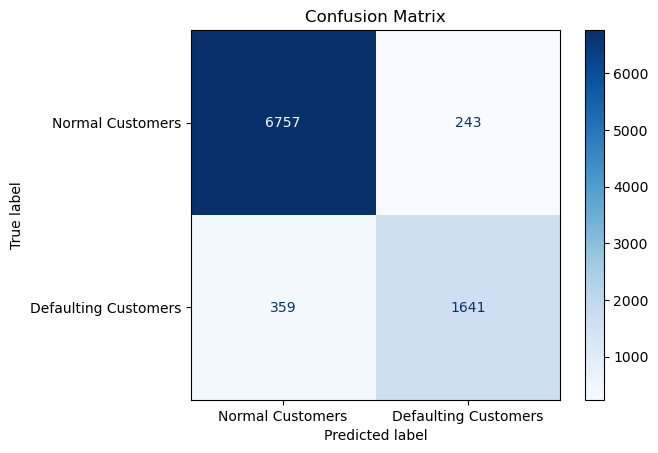


--- 结束 ---


In [25]:
# --- 6. 结果展示 ---
print("\n--- 分类报告 ---")
# target_names 可以根据你的标签含义修改，这里假设 0=未违约, 1=违约
report = classification_report(all_labels, all_preds, target_names=['Normal Customers', 'Defaulting Customers'])
print(report)

print("\n--- 混淆矩阵 ---")
cm = confusion_matrix(all_labels, all_preds)
print(cm)

# 可视化混淆矩阵
try:
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal Customers', 'Defaulting Customers'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.show()
except ImportError:
    print("\n请安装 matplotlib 和 seaborn 以显示混淆矩阵图：pip install matplotlib seaborn")

print("\n--- 结束 ---")